# 📚 DataFrames and Data Visualization Tutorial

## Learning Objectives

By the end of this tutorial, you will:
- Understand what a DataFrame is and why we use it
- Learn how to load CSV files into pandas DataFrames
- Explore data structure and basic information
- Create meaningful visualizations step by step
- Interpret the results

---

## What is a DataFrame?

A **DataFrame** is a two-dimensional data structure (like a spreadsheet or table) that:
- Has rows (observations) and columns (variables)
- Makes data manipulation and analysis easier
- Is the primary data structure in pandas (Python Data Analysis Library)

Think of it as an Excel spreadsheet, but much more powerful!

### Why Use DataFrames?
- **Easy data loading**: Read CSV, Excel, JSON files easily
- **Data cleaning**: Handle missing values, filter data
- **Data analysis**: Calculate statistics, group data
- **Visualization**: Create charts and plots
- **Integration**: Works seamlessly with visualization libraries

## Step 1: Import Required Libraries

Before we can work with DataFrames, we need to import the necessary libraries.

### Libraries We'll Use:
- **pandas (pd)**: For DataFrames and data manipulation
- **numpy (np)**: For numerical operations
- **matplotlib.pyplot (plt)**: For creating plots and charts
- **seaborn (sns)**: For beautiful statistical visualizations
- **Path**: For handling file paths easily

In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline  # Display plots inline in the notebook

print("✅ Libraries imported successfully!")
print(f"📦 Pandas version: {pd.__version__}")
print(f"📦 NumPy version: {np.__version__}")

UsageError: unrecognized arguments: # Display plots inline in the notebook


## Step 2: Understanding the Dataset Path

Before loading data, we need to know where our files are located.

### What is a Path?
- A path tells the computer where to find a file
- We use `Path` from `pathlib` to handle file paths easily
- This works on Windows, Mac, and Linux

### Our Dataset Location:
The CSV files we converted are located in the `CMAPSSData` folder.

In [2]:
# Define the path to our dataset
data_path = Path('dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData')

# Check if the path exists
if data_path.exists():
    print(f"✅ Dataset path found: {data_path}")
    print(f"📁 Absolute path: {data_path.absolute()}")
else:
    print(f"❌ Path not found: {data_path}")
    print("Please check the path and try again.")

✅ Dataset path found: dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData
📁 Absolute path: /home/pawatchun/Desktop/teaching/turbofan/dataset/6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData


## Step 3: List Available Files

Let's see what CSV files are available in our dataset folder.

### Why Check Available Files?
- Verify that our CSV files were created successfully
- See all available datasets (FD001, FD002, FD003, FD004)
- Understand the file naming convention

In [3]:
# List all CSV files in the dataset directory
csv_files = list(data_path.glob('*.csv'))

print(f"📊 Found {len(csv_files)} CSV files:\n")
print("=" * 60)

# Group files by type
train_files = [f for f in csv_files if 'train' in f.name]
test_files = [f for f in csv_files if 'test' in f.name]
rul_files = [f for f in csv_files if 'RUL' in f.name]

print("\n📈 Training Files:")
for f in sorted(train_files):
    print(f"   - {f.name}")

print("\n🧪 Test Files:")
for f in sorted(test_files):
    print(f"   - {f.name}")

print("\n⏱️  RUL Files:")
for f in sorted(rul_files):
    print(f"   - {f.name}")

print("\n" + "=" * 60)

📊 Found 12 CSV files:


📈 Training Files:
   - train_FD001.csv
   - train_FD002.csv
   - train_FD003.csv
   - train_FD004.csv

🧪 Test Files:
   - test_FD001.csv
   - test_FD002.csv
   - test_FD003.csv
   - test_FD004.csv

⏱️  RUL Files:
   - RUL_FD001.csv
   - RUL_FD002.csv
   - RUL_FD003.csv
   - RUL_FD004.csv



## Step 4: Load Your First DataFrame

Now let's load a CSV file into a pandas DataFrame!

### What is `pd.read_csv()`?
- A function that reads CSV (Comma-Separated Values) files
- Automatically creates a DataFrame
- Handles headers, data types, and formatting

### Understanding the Parameters:
- **File path**: Where the CSV file is located
- **index_col**: (Optional) Which column to use as row index
- **sep**: (Optional) Separator character (default is comma)

Let's start with the training data for FD001.

In [4]:
# Load the training data for FD001 into a DataFrame
train_file = data_path / 'train_FD001.csv'

# Read the CSV file
train_df = pd.read_csv(train_file)

print("✅ DataFrame loaded successfully!")
print(f"📊 File: {train_file.name}")
print(f"\n📏 DataFrame shape: {train_df.shape}")
print(f"   - Rows (observations): {train_df.shape[0]:,}")
print(f"   - Columns (variables): {train_df.shape[1]}")

✅ DataFrame loaded successfully!
📊 File: train_FD001.csv

📏 DataFrame shape: (20631, 26)
   - Rows (observations): 20,631
   - Columns (variables): 26


## Step 5: Explore the DataFrame Structure

Let's examine what our DataFrame looks like!

### Key Methods to Explore Data:
- **`.head()`**: Show first few rows (default: 5)
- **`.tail()`**: Show last few rows
- **`.info()`**: Show data types and memory usage
- **`.describe()`**: Show statistical summary
- **`.columns`**: List all column names

In [5]:
# Display the first 10 rows of the DataFrame
print("📋 First 10 Rows of the DataFrame:")
print("=" * 80)
train_df.head(10)

📋 First 10 Rows of the DataFrame:


,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
5,1,6,-0.0043,-0.0001,100.0,518.67,642.10,1584.47,1398.37,14.62,...,521.68,2388.03,8132.85,8.4108,0.03,391,2388,100.0,38.98,23.3669
6,1,7,0.0010,0.0001,100.0,518.67,642.48,1592.32,1397.77,14.62,...,522.32,2388.03,8132.32,8.3974,0.03,392,2388,100.0,39.10,23.3774
7,1,8,-0.0034,0.0003,100.0,518.67,642.56,1582.96,1400.97,14.62,...,522.47,2388.03,8131.07,8.4076,0.03,391,2388,100.0,38.97,23.3106
8,1,9,0.0008,0.0001,100.0,518.67,642.12,1590.98,1394.80,14.62,...,521.79,2388.05,8125.69,8.3728,0.03,392,2388,100.0,39.05,23.4066
9,1,10,-0.0033,0.0001,100.0,518.67,641.71,1591.24,1400.46,14.62,...,521.79,2388.06,8129.38,8.4286,0.03,393,2388,100.0,38.95,23.4694


In [6]:
# Display the last 5 rows
print("📋 Last 5 Rows of the DataFrame:")
print("=" * 80)
train_df.tail()

📋 Last 5 Rows of the DataFrame:


,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [7]:
# Get information about the DataFrame
print("ℹ️  DataFrame Information:")
print("=" * 80)
train_df.info()

ℹ️  DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit       20631 non-null  int64  
 1   time       20631 non-null  int64  
 2   Altitude   20631 non-null  float64
 3   Mach       20631 non-null  float64
 4   TRA        20631 non-null  float64
 5   T2         20631 non-null  float64
 6   T24        20631 non-null  float64
 7   T30        20631 non-null  float64
 8   T50        20631 non-null  float64
 9   P2         20631 non-null  float64
 10  P15        20631 non-null  float64
 11  P30        20631 non-null  float64
 12  Nf         20631 non-null  float64
 13  Nc         20631 non-null  float64
 14  epr        20631 non-null  float64
 15  Ps30       20631 non-null  float64
 16  phi        20631 non-null  float64
 17  NRf        20631 non-null  float64
 18  NRc        20631 non-null  float64
 19  BPR        20631 no

In [8]:
# Display column names
print("📝 Column Names:")
print("=" * 80)
print(f"Total columns: {len(train_df.columns)}\n")
for i, col in enumerate(train_df.columns, 1):
    print(f"{i:2d}. {col}")

📝 Column Names:
Total columns: 26

 1. unit
 2. time
 3. Altitude
 4. Mach
 5. TRA
 6. T2
 7. T24
 8. T30
 9. T50
10. P2
11. P15
12. P30
13. Nf
14. Nc
15. epr
16. Ps30
17. phi
18. NRf
19. NRc
20. BPR
21. farB
22. htBleed
23. Nf_dmd
24. PCNfR_dmd
25. W31
26. W32


In [9]:
# Get statistical summary of numerical columns
print("📊 Statistical Summary:")
print("=" * 80)
print("\nThis shows:")
print("  - count: Number of non-null values")
print("  - mean: Average value")
print("  - std: Standard deviation (spread of data)")
print("  - min: Minimum value")
print("  - 25%: 25th percentile (Q1)")
print("  - 50%: Median (50th percentile)")
print("  - 75%: 75th percentile (Q3)")
print("  - max: Maximum value")
print("\n" + "=" * 80)
train_df.describe()

📊 Statistical Summary:

This shows:
  - count: Number of non-null values
  - mean: Average value
  - std: Standard deviation (spread of data)
  - min: Minimum value
  - 25%: 25th percentile (Q1)
  - 50%: Median (50th percentile)
  - 75%: 75th percentile (Q3)
  - max: Maximum value



,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


## Step 6: Understanding the Data Columns

Let's understand what each column represents in our turbofan engine dataset.

### Column Categories:

1. **Identifier Columns**:
   - `unit`: Engine unit number (which engine)
   - `time`: Time in cycles (operational cycles)

2. **Operational Settings** (3 columns):
   - `Altitude`: Flight altitude
   - `Mach`: Mach number (speed)
   - `TRA`: Throttle resolver angle

3. **Sensor Measurements** (21 columns):
   - Temperature sensors: T2, T24, T30, T50
   - Pressure sensors: P2, P15, P30, Ps30
   - Speed sensors: Nf, Nc, NRf, NRc
   - Other sensors: epr, phi, BPR, farB, htBleed, etc.

In [10]:
# Let's examine specific columns
print("🔍 Examining Key Columns:")
print("=" * 80)

# Check unique engine units
unique_units = train_df['unit'].unique()
print(f"\n🚁 Number of unique engines: {len(unique_units)}")
print(f"   Engine IDs: {unique_units[:10]}..." if len(unique_units) > 10 else f"   Engine IDs: {unique_units}")

# Check time range
print(f"\n⏱️  Time (cycles) range:")
print(f"   Minimum: {train_df['time'].min()}")
print(f"   Maximum: {train_df['time'].max()}")

# Check operational settings
print(f"\n⚙️  Operational Settings:")
for col in ['Altitude', 'Mach', 'TRA']:
    print(f"   {col}: min={train_df[col].min():.4f}, max={train_df[col].max():.4f}, mean={train_df[col].mean():.4f}")

🔍 Examining Key Columns:

🚁 Number of unique engines: 100
   Engine IDs: [ 1  2  3  4  5  6  7  8  9 10]...

⏱️  Time (cycles) range:
   Minimum: 1
   Maximum: 362

⚙️  Operational Settings:
   Altitude: min=-0.0087, max=0.0087, mean=-0.0000
   Mach: min=-0.0006, max=0.0006, mean=0.0000
   TRA: min=100.0000, max=100.0000, mean=100.0000


## Step 7: Your First Visualization - Basic Line Plot

Now let's create our first visualization!

### What is a Line Plot?
- Shows how a value changes over time
- Perfect for time series data
- X-axis: time, Y-axis: the value we're measuring

### Let's visualize sensor readings for one engine over time.

In [11]:
# Select data for one engine (unit 1)
engine_1 = train_df[train_df['unit'] == 1].copy()

print(f"📊 Data for Engine #1:")
print(f"   Total cycles: {len(engine_1)}")
print(f"   Time range: {engine_1['time'].min()} to {engine_1['time'].max()} cycles")

# Display first few rows
engine_1.head()

📊 Data for Engine #1:
   Total cycles: 192
   Time range: 1 to 192 cycles


,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


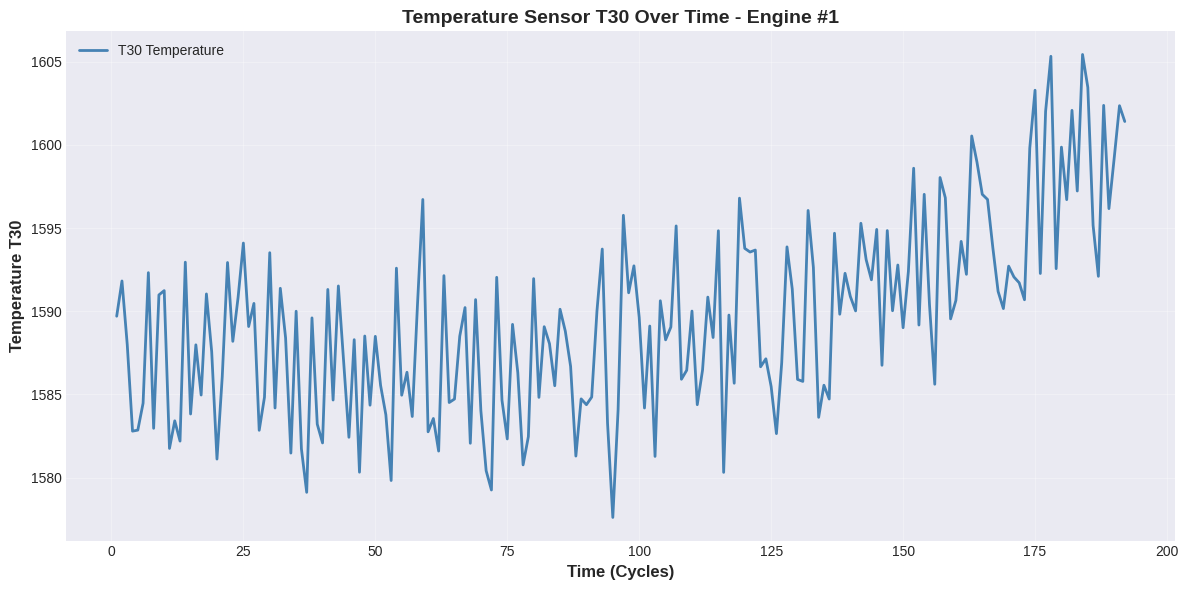

✅ First plot created successfully!


In [12]:
# Create our first plot: Temperature sensor T30 over time
plt.figure(figsize=(12, 6))  # Set figure size (width, height in inches)

# Plot the data
plt.plot(engine_1['time'], engine_1['T30'], 
         linewidth=2, color='steelblue', label='T30 Temperature')

# Add labels and title
plt.xlabel('Time (Cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Temperature T30', fontsize=12, fontweight='bold')
plt.title('Temperature Sensor T30 Over Time - Engine #1', 
          fontsize=14, fontweight='bold')

# Add grid for easier reading
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(fontsize=10)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

print("✅ First plot created successfully!")

## Step 8: Multiple Sensors on One Plot

Let's compare multiple sensors on the same plot to see relationships.

### Why Compare Multiple Sensors?
- See how different sensors behave together
- Identify correlations
- Understand engine behavior patterns

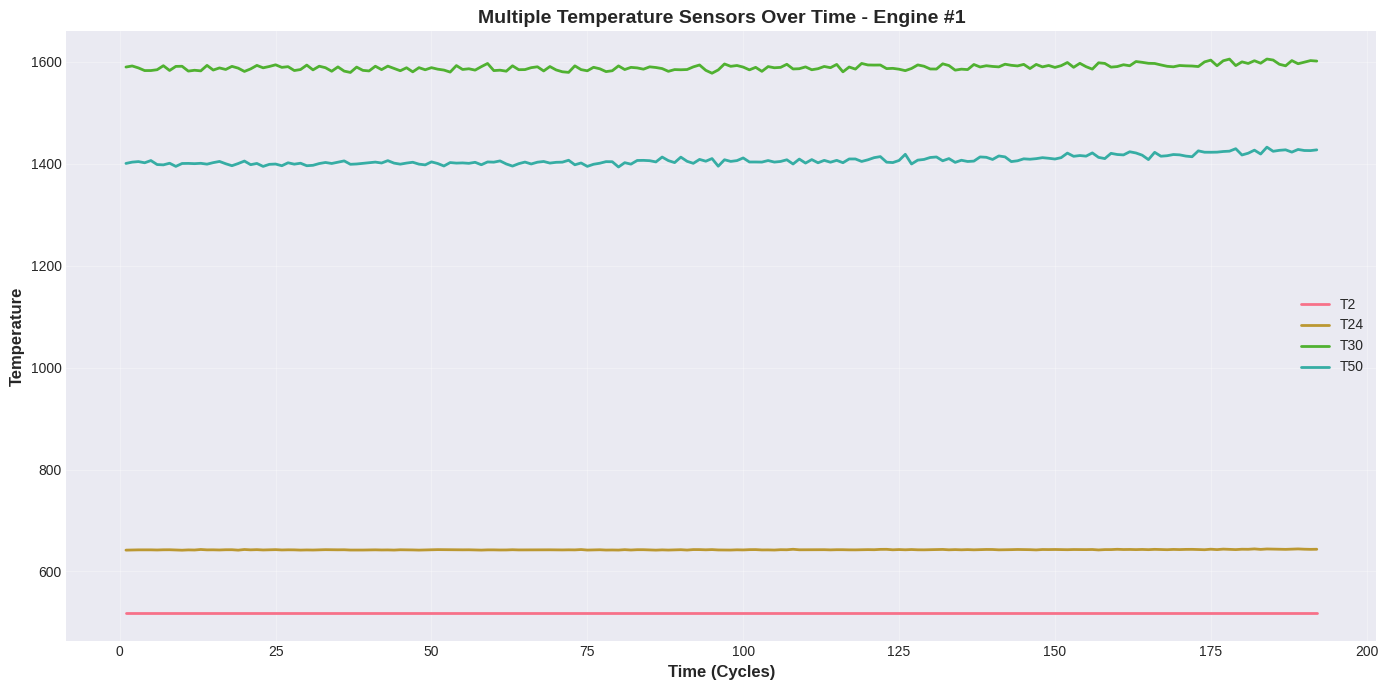

✅ Multiple sensors plotted!


In [13]:
# Create a plot with multiple temperature sensors
plt.figure(figsize=(14, 7))

# Plot multiple sensors
plt.plot(engine_1['time'], engine_1['T2'], label='T2', linewidth=2)
plt.plot(engine_1['time'], engine_1['T24'], label='T24', linewidth=2)
plt.plot(engine_1['time'], engine_1['T30'], label='T30', linewidth=2)
plt.plot(engine_1['time'], engine_1['T50'], label='T50', linewidth=2)

# Customize the plot
plt.xlabel('Time (Cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Temperature', fontsize=12, fontweight='bold')
plt.title('Multiple Temperature Sensors Over Time - Engine #1', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Multiple sensors plotted!")

## Step 9: Subplots - Multiple Plots in One Figure

Sometimes it's better to show multiple plots separately using subplots.

### What are Subplots?
- Multiple plots arranged in a grid
- Each plot can show different data
- Makes comparisons easier

### Syntax: `plt.subplots(rows, cols)`

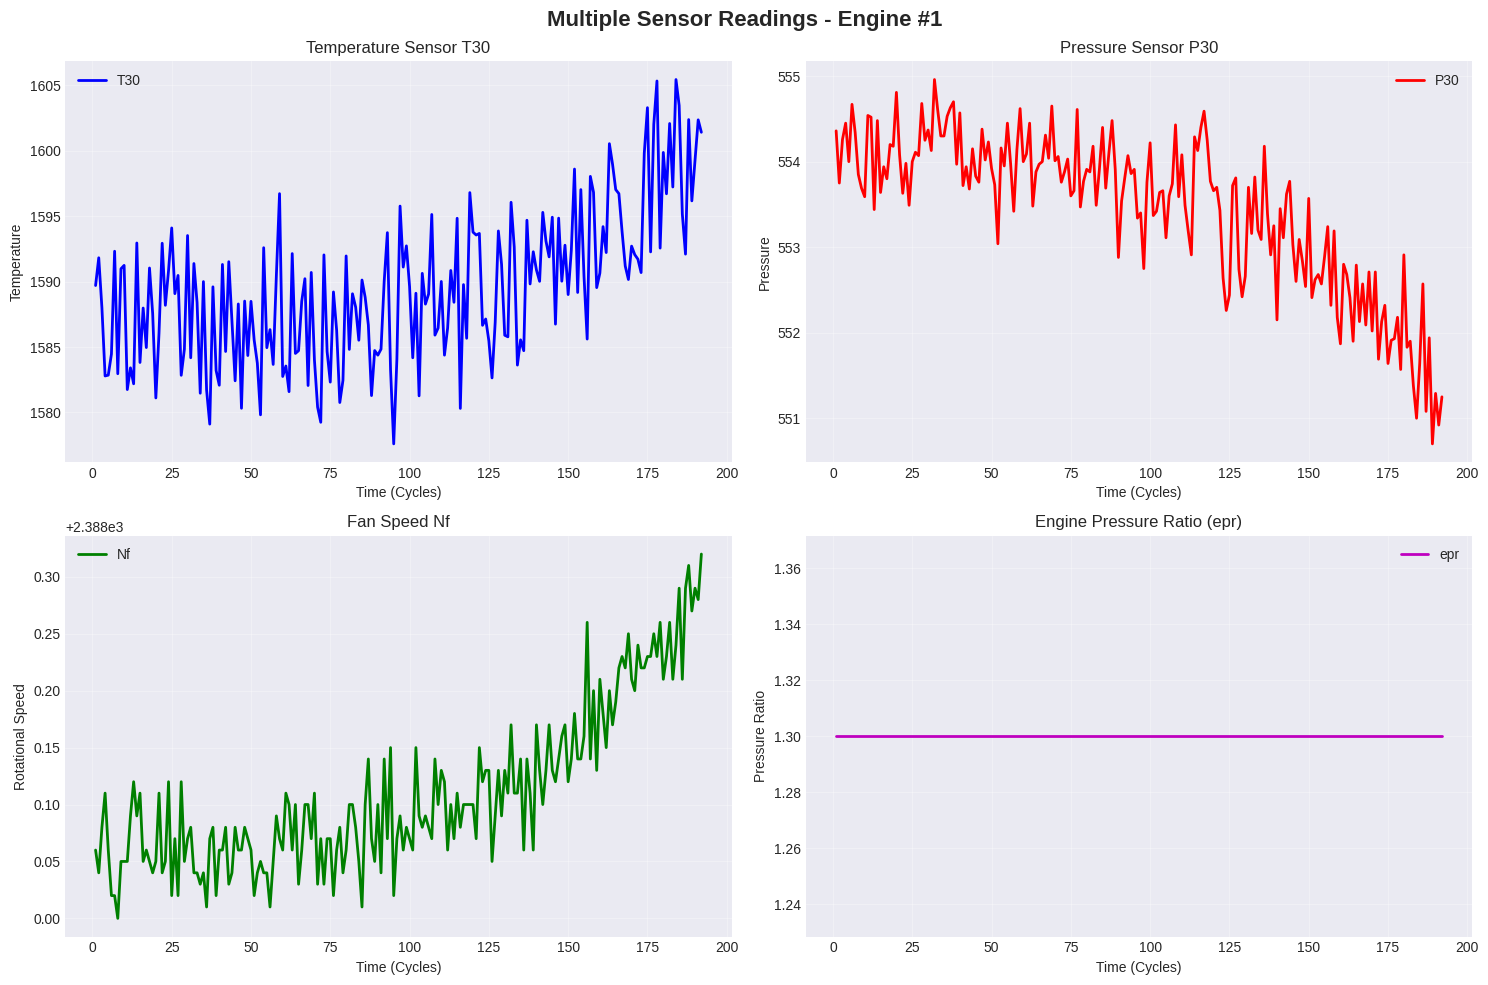

✅ Subplots created!


In [14]:
# Create a figure with 2 rows and 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Multiple Sensor Readings - Engine #1', fontsize=16, fontweight='bold')

# Plot 1: Temperature sensors
axes[0, 0].plot(engine_1['time'], engine_1['T30'], 'b-', linewidth=2, label='T30')
axes[0, 0].set_xlabel('Time (Cycles)')
axes[0, 0].set_ylabel('Temperature')
axes[0, 0].set_title('Temperature Sensor T30')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Pressure sensors
axes[0, 1].plot(engine_1['time'], engine_1['P30'], 'r-', linewidth=2, label='P30')
axes[0, 1].set_xlabel('Time (Cycles)')
axes[0, 1].set_ylabel('Pressure')
axes[0, 1].set_title('Pressure Sensor P30')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Rotational speed
axes[1, 0].plot(engine_1['time'], engine_1['Nf'], 'g-', linewidth=2, label='Nf')
axes[1, 0].set_xlabel('Time (Cycles)')
axes[1, 0].set_ylabel('Rotational Speed')
axes[1, 0].set_title('Fan Speed Nf')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Engine pressure ratio
axes[1, 1].plot(engine_1['time'], engine_1['epr'], 'm-', linewidth=2, label='epr')
axes[1, 1].set_xlabel('Time (Cycles)')
axes[1, 1].set_ylabel('Pressure Ratio')
axes[1, 1].set_title('Engine Pressure Ratio (epr)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("✅ Subplots created!")

## Step 10: Comparing Multiple Engines

Let's compare the same sensor across different engines to see variations.

### Why Compare Engines?
- See how different engines behave
- Identify patterns or anomalies
- Understand engine-to-engine variation

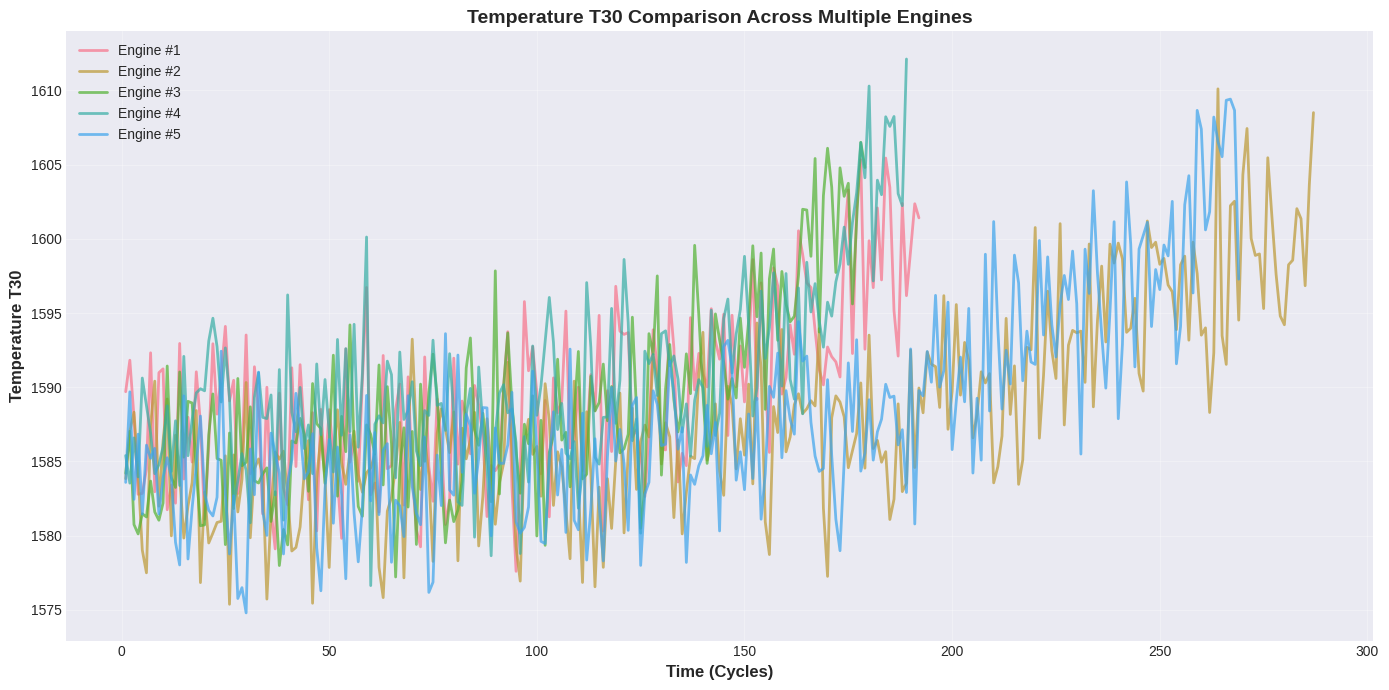

✅ Multiple engines compared!


In [15]:
# Select a few engines to compare
engines_to_plot = [1, 2, 3, 4, 5]

plt.figure(figsize=(14, 7))

# Plot T30 sensor for each engine
for engine_id in engines_to_plot:
    engine_data = train_df[train_df['unit'] == engine_id]
    plt.plot(engine_data['time'], engine_data['T30'], 
             linewidth=2, label=f'Engine #{engine_id}', alpha=0.7)

plt.xlabel('Time (Cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Temperature T30', fontsize=12, fontweight='bold')
plt.title('Temperature T30 Comparison Across Multiple Engines', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Multiple engines compared!")

## Step 11: Histogram - Understanding Data Distribution

A histogram shows the distribution of values in a column.

### What is a Histogram?
- Shows how often different values occur
- X-axis: value ranges (bins)
- Y-axis: frequency (how many times)
- Helps understand data distribution patterns

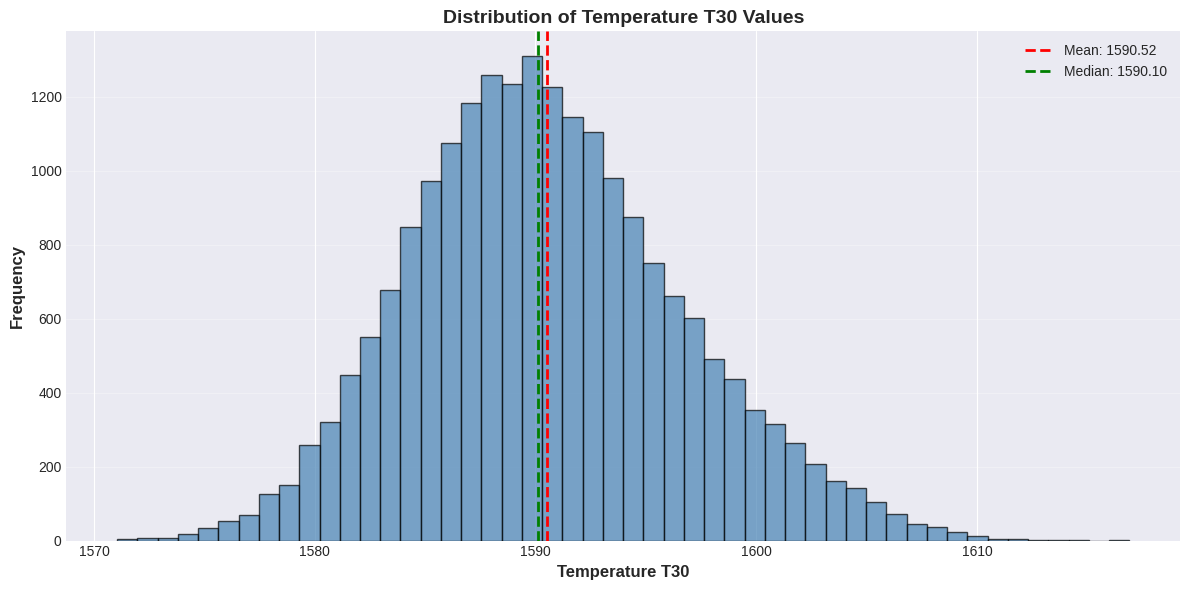

📊 Statistics:
   Mean: 1590.52
   Median: 1590.10
   Std Dev: 6.13


In [16]:
# Create a histogram of T30 temperature values
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(train_df['T30'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Add labels
plt.xlabel('Temperature T30', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of Temperature T30 Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add statistics text
mean_val = train_df['T30'].mean()
median_val = train_df['T30'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"📊 Statistics:")
print(f"   Mean: {mean_val:.2f}")
print(f"   Median: {median_val:.2f}")
print(f"   Std Dev: {train_df['T30'].std():.2f}")

## Step 12: Box Plot - Understanding Data Spread

A box plot (box-and-whisker plot) shows the distribution of data.

### What Does a Box Plot Show?
- **Median**: Middle line (50th percentile)
- **Box**: Interquartile range (25th to 75th percentile)
- **Whiskers**: Range of data (excluding outliers)
- **Outliers**: Points beyond the whiskers

### Why Use Box Plots?
- Compare distributions across different groups
- Identify outliers
- See data spread and skewness

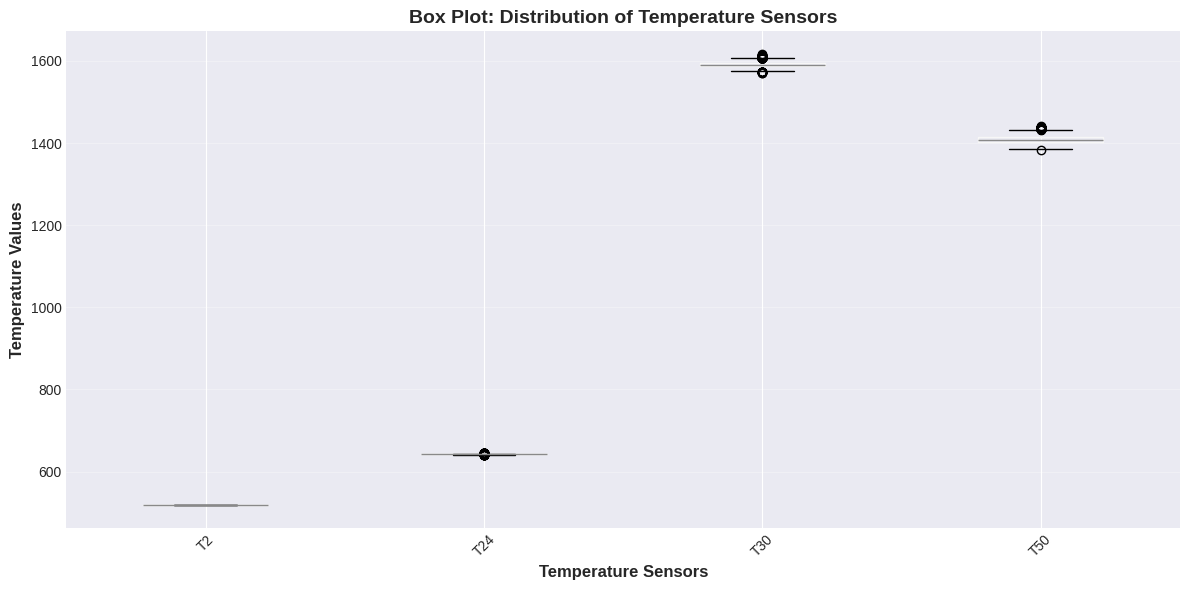

✅ Box plot created!


In [17]:
# Create box plots for multiple sensors
sensors_to_plot = ['T2', 'T24', 'T30', 'T50']

plt.figure(figsize=(12, 6))

# Create box plot
train_df[sensors_to_plot].boxplot()

plt.xlabel('Temperature Sensors', fontsize=12, fontweight='bold')
plt.ylabel('Temperature Values', fontsize=12, fontweight='bold')
plt.title('Box Plot: Distribution of Temperature Sensors', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("✅ Box plot created!")

## Step 13: Correlation Heatmap - Finding Relationships

A correlation heatmap shows how variables are related to each other.

### What is Correlation?
- Measures how two variables change together
- Values range from -1 to +1
  - **+1**: Perfect positive correlation (both increase together)
  - **0**: No correlation (independent)
  - **-1**: Perfect negative correlation (one increases, other decreases)

### Why Use Heatmaps?
- Quickly identify relationships
- Find which sensors are related
- Visual representation is easy to interpret

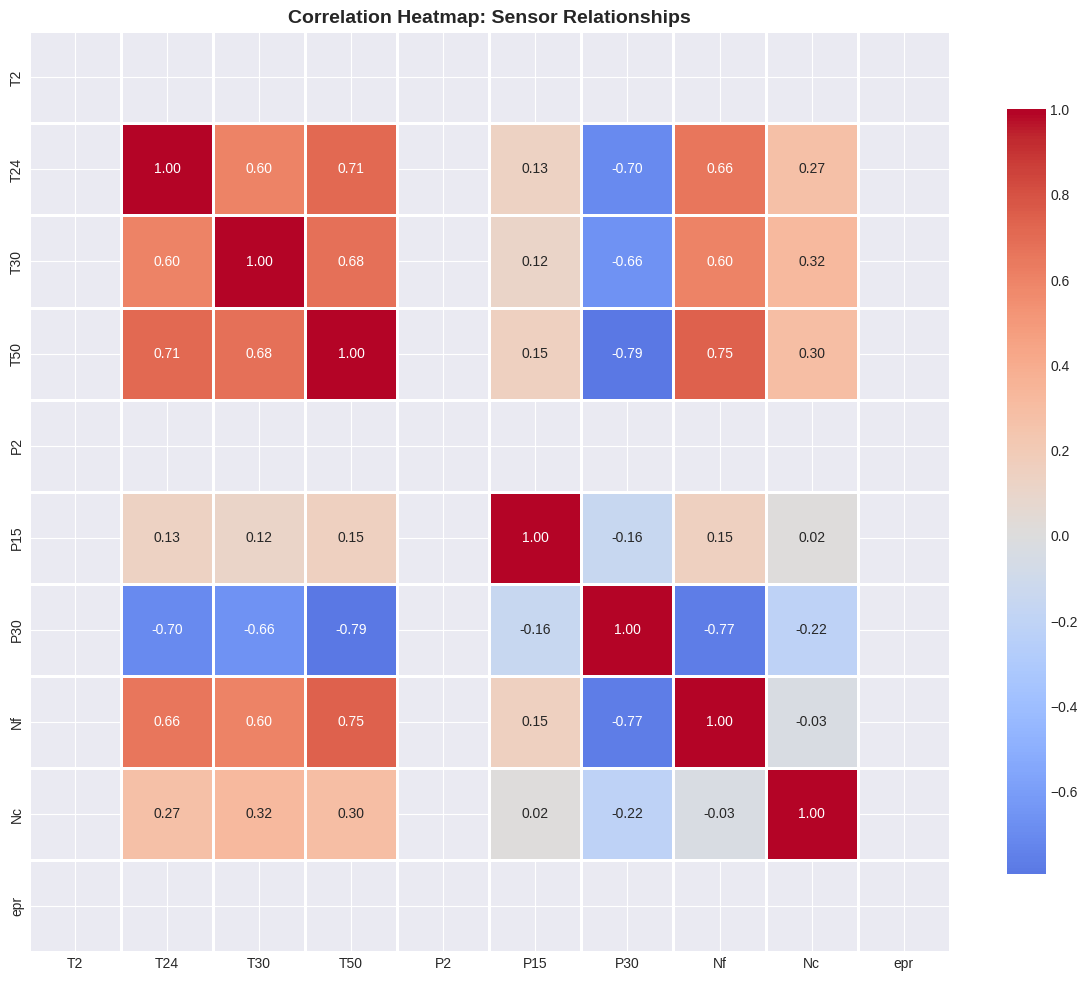

✅ Correlation heatmap created!

💡 Interpretation:
   - Red/positive values: Variables increase together
   - Blue/negative values: Variables move in opposite directions
   - Values closer to 1 or -1 indicate stronger relationships


In [18]:
# Select sensor columns for correlation analysis
sensor_columns = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr']

# Calculate correlation matrix
correlation_matrix = train_df[sensor_columns].corr()

# Create heatmap using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap: Sensor Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Correlation heatmap created!")
print("\n💡 Interpretation:")
print("   - Red/positive values: Variables increase together")
print("   - Blue/negative values: Variables move in opposite directions")
print("   - Values closer to 1 or -1 indicate stronger relationships")

## Step 14: Scatter Plot - Relationship Between Two Variables

A scatter plot shows the relationship between two variables.

### What is a Scatter Plot?
- Each point represents one observation
- X-axis: one variable
- Y-axis: another variable
- Shows correlation visually

### When to Use Scatter Plots?
- Explore relationships between two variables
- Identify patterns or clusters
- Detect outliers

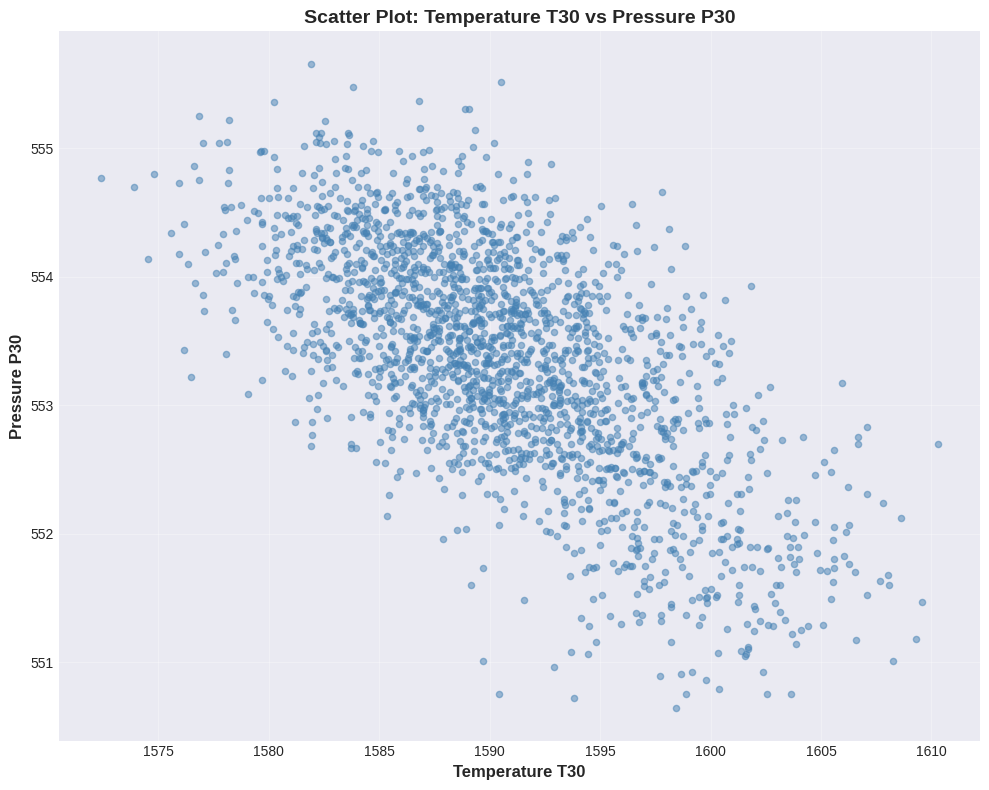

📊 Correlation between T30 and P30: -0.6646

💡 Interpretation:
   Negative relationship


In [19]:
# Create scatter plot: T30 vs P30
plt.figure(figsize=(10, 8))

# Sample data for faster plotting (use every 10th row)
sample_df = train_df.iloc[::10]

plt.scatter(sample_df['T30'], sample_df['P30'], alpha=0.5, s=20, c='steelblue')

plt.xlabel('Temperature T30', fontsize=12, fontweight='bold')
plt.ylabel('Pressure P30', fontsize=12, fontweight='bold')
plt.title('Scatter Plot: Temperature T30 vs Pressure P30', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = train_df['T30'].corr(train_df['P30'])
print(f"📊 Correlation between T30 and P30: {correlation:.4f}")
print("\n💡 Interpretation:")
if correlation > 0.7:
    print("   Strong positive relationship - as temperature increases, pressure increases")
elif correlation > 0.3:
    print("   Moderate positive relationship")
elif correlation > -0.3:
    print("   Weak relationship")
else:
    print("   Negative relationship")

## Step 15: Loading and Visualizing Test Data

Now let's load the test dataset and compare it with training data.

### Training vs Test Data:
- **Training**: Complete run-to-failure data (we know when engines failed)
- **Test**: Partial data (we need to predict when engines will fail)

Let's load and explore the test data.

In [20]:
# Load test data
test_file = data_path / 'test_FD001.csv'
test_df = pd.read_csv(test_file)

print("✅ Test DataFrame loaded!")
print(f"📊 File: {test_file.name}")
print(f"\n📏 Test DataFrame shape: {test_df.shape}")
print(f"   - Rows: {test_df.shape[0]:,}")
print(f"   - Columns: {test_df.shape[1]}")
print(f"\n🚁 Number of engines in test set: {test_df['unit'].nunique()}")
print(f"⏱️  Time range: {test_df['time'].min()} to {test_df['time'].max()} cycles")

# Display first few rows
print("\n📋 First 5 rows:")
test_df.head()

✅ Test DataFrame loaded!
📊 File: test_FD001.csv

📏 Test DataFrame shape: (13096, 26)
   - Rows: 13,096
   - Columns: 26

🚁 Number of engines in test set: 100
⏱️  Time range: 1 to 303 cycles

📋 First 5 rows:


,unit,time,Altitude,Mach,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


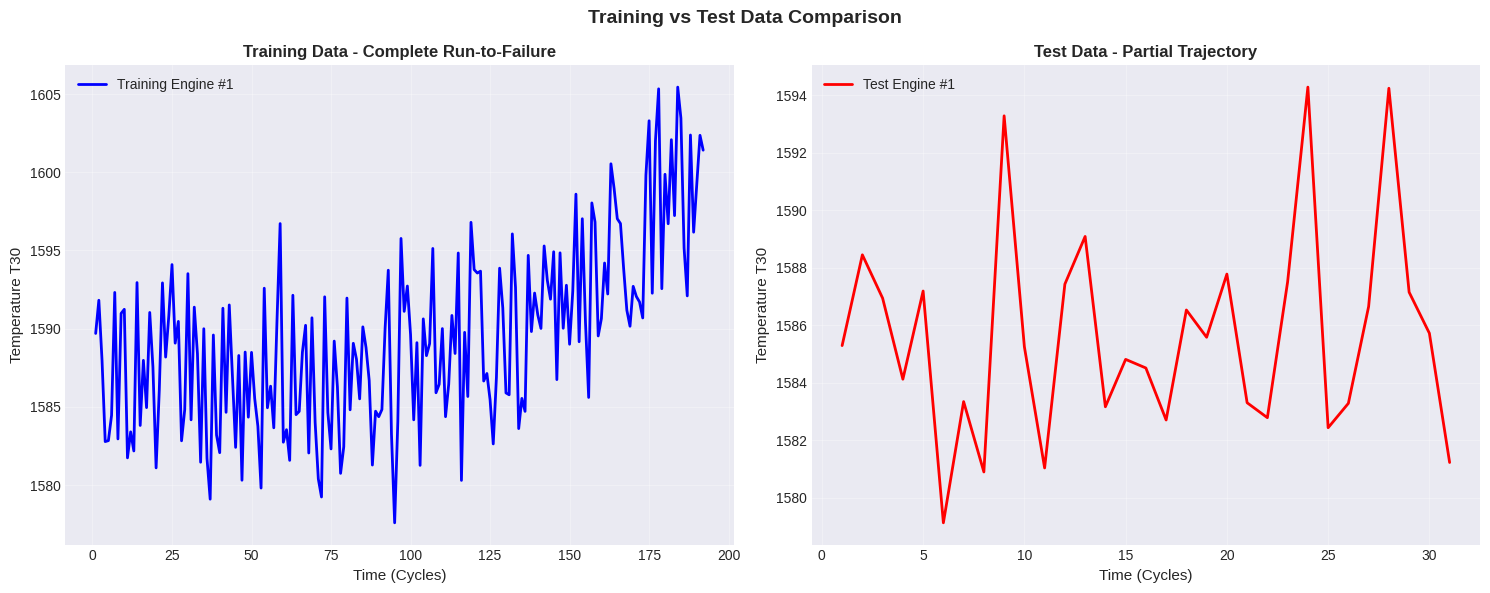

📊 Training engine #1 cycles: 192
📊 Test engine #1 cycles: 31


In [21]:
# Compare training vs test data
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Training data - T30 for first engine
train_engine_1 = train_df[train_df['unit'] == 1]
axes[0].plot(train_engine_1['time'], train_engine_1['T30'], 'b-', linewidth=2, label='Training Engine #1')
axes[0].set_xlabel('Time (Cycles)', fontsize=11)
axes[0].set_ylabel('Temperature T30', fontsize=11)
axes[0].set_title('Training Data - Complete Run-to-Failure', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Test data - T30 for first engine
test_engine_1 = test_df[test_df['unit'] == 1]
axes[1].plot(test_engine_1['time'], test_engine_1['T30'], 'r-', linewidth=2, label='Test Engine #1')
axes[1].set_xlabel('Time (Cycles)', fontsize=11)
axes[1].set_ylabel('Temperature T30', fontsize=11)
axes[1].set_title('Test Data - Partial Trajectory', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('Training vs Test Data Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"📊 Training engine #1 cycles: {len(train_engine_1)}")
print(f"📊 Test engine #1 cycles: {len(test_engine_1)}")

## Step 16: Loading RUL (Remaining Useful Life) Data

RUL tells us how many cycles each engine has left before failure.

### What is RUL?
- **Remaining Useful Life**: Number of cycles until engine failure
- Used as the target variable for prediction
- In test data, RUL values are provided for evaluation

In [22]:
# Load RUL data
rul_file = data_path / 'RUL_FD001.csv'
rul_df = pd.read_csv(rul_file)

print("✅ RUL DataFrame loaded!")
print(f"📊 File: {rul_file.name}")
print(f"\n📏 RUL DataFrame shape: {rul_df.shape}")
print(f"   - Number of engines: {len(rul_df)}")
print(f"   - Columns: {list(rul_df.columns)}")

# Display first 10 rows
print("\n📋 First 10 RUL values:")
rul_df.head(10)

✅ RUL DataFrame loaded!
📊 File: RUL_FD001.csv

📏 RUL DataFrame shape: (100, 1)
   - Number of engines: 100
   - Columns: ['RUL']

📋 First 10 RUL values:


,RUL
0,112
1,98
2,69
3,82
4,91
5,93
6,91
7,95
8,111
9,96


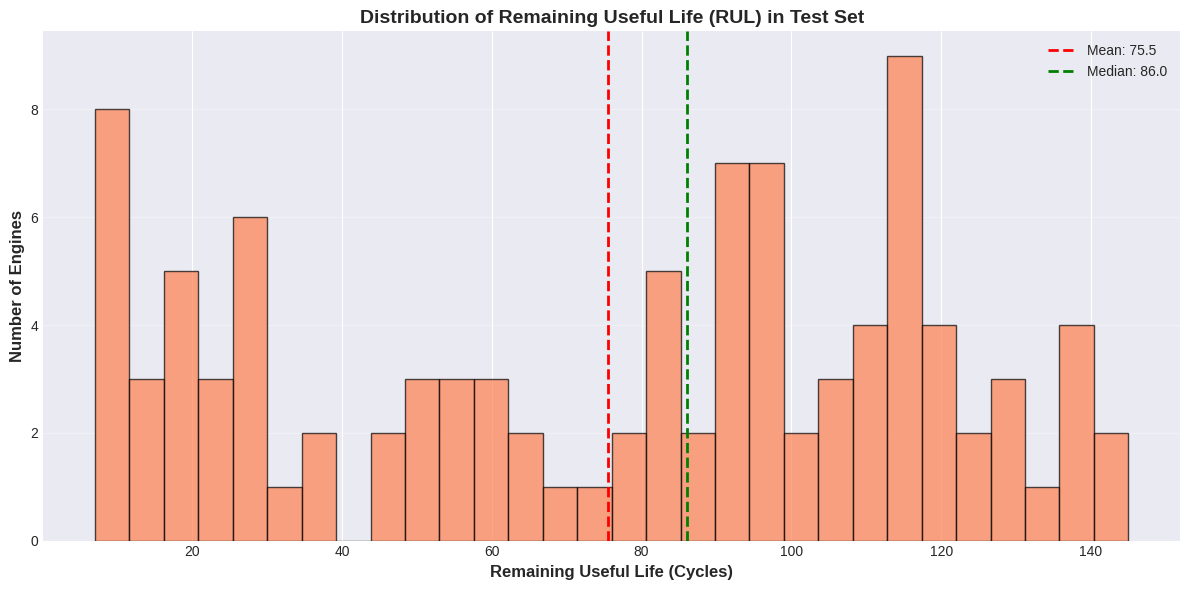

📊 RUL Statistics:
   Mean: 75.52 cycles
   Median: 86.00 cycles
   Min: 7 cycles
   Max: 145 cycles
   Std Dev: 41.76 cycles


In [23]:
# Visualize RUL distribution
plt.figure(figsize=(12, 6))

# Create histogram
plt.hist(rul_df['RUL'], bins=30, color='coral', edgecolor='black', alpha=0.7)

plt.xlabel('Remaining Useful Life (Cycles)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Engines', fontsize=12, fontweight='bold')
plt.title('Distribution of Remaining Useful Life (RUL) in Test Set', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add statistics
mean_rul = rul_df['RUL'].mean()
median_rul = rul_df['RUL'].median()
plt.axvline(mean_rul, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_rul:.1f}')
plt.axvline(median_rul, color='green', linestyle='--', linewidth=2, label=f'Median: {median_rul:.1f}')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"📊 RUL Statistics:")
print(f"   Mean: {mean_rul:.2f} cycles")
print(f"   Median: {median_rul:.2f} cycles")
print(f"   Min: {rul_df['RUL'].min()} cycles")
print(f"   Max: {rul_df['RUL'].max()} cycles")
print(f"   Std Dev: {rul_df['RUL'].std():.2f} cycles")

## Step 17: Advanced Visualization - Engine Degradation Over Time

Let's create a comprehensive visualization showing how engines degrade over time.

### What We'll Show:
- Multiple engines on one plot
- How sensor values change as engines approach failure
- Visual representation of degradation patterns

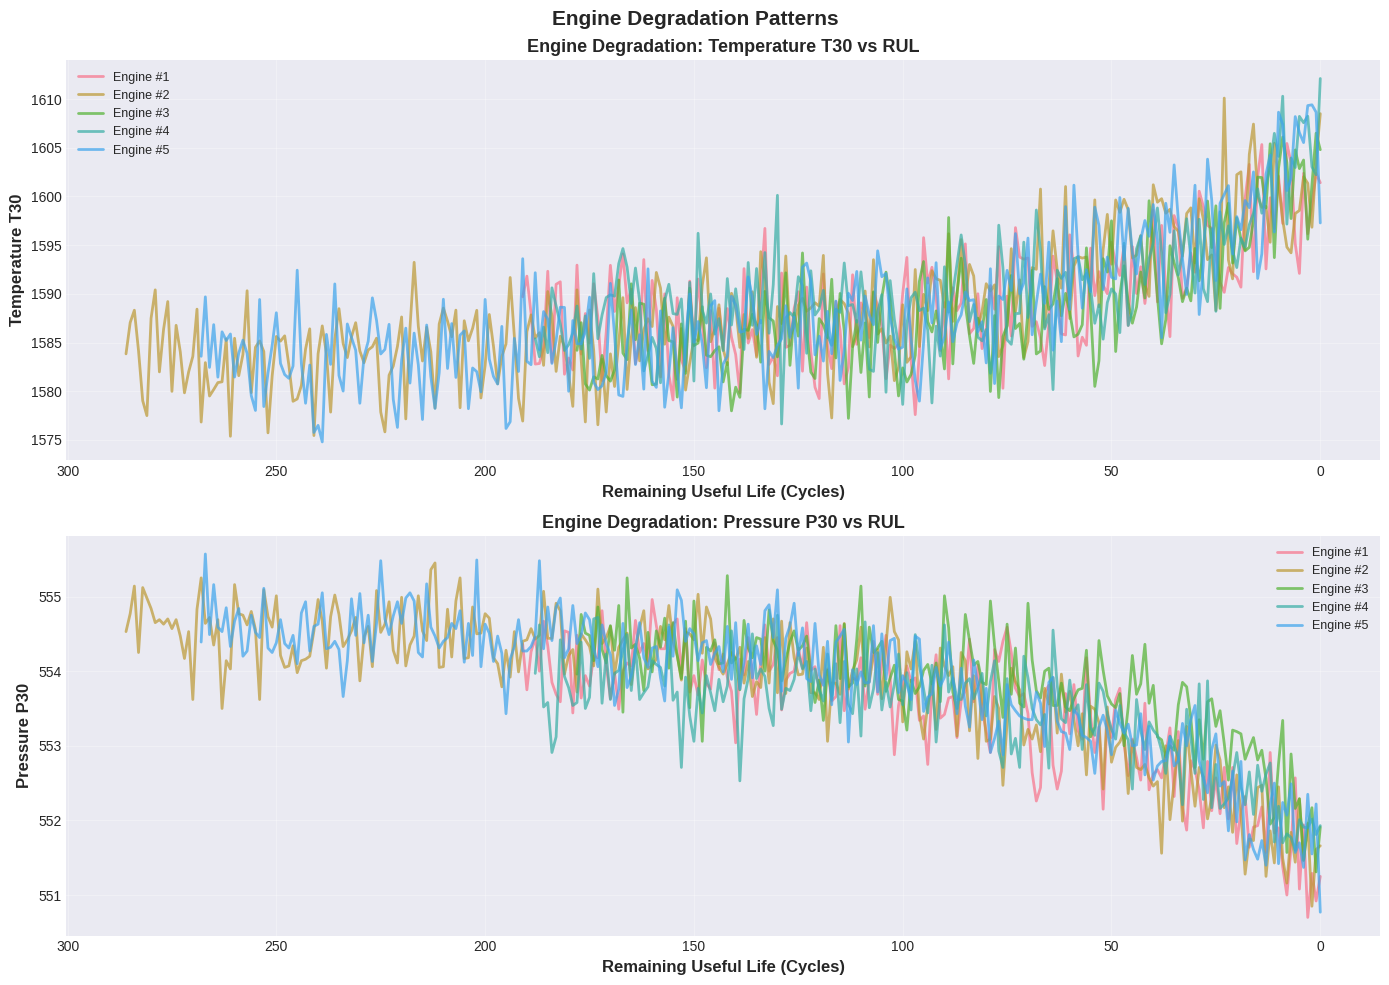

✅ Degradation visualization created!

💡 Observation: Notice how sensor values change as engines approach failure (RUL → 0)


In [24]:
# Calculate RUL for training data (time until failure)
train_df_with_rul = train_df.copy()
train_df_with_rul['RUL'] = train_df_with_rul.groupby('unit')['time'].transform(
    lambda x: x.max() - x
)

# Select a few engines
engines_to_plot = [1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Temperature T30 vs RUL (showing degradation)
for engine_id in engines_to_plot:
    engine_data = train_df_with_rul[train_df_with_rul['unit'] == engine_id]
    # Sort by RUL (descending) to show progression toward failure
    engine_data_sorted = engine_data.sort_values('RUL', ascending=False)
    axes[0].plot(engine_data_sorted['RUL'], engine_data_sorted['T30'], 
                linewidth=2, label=f'Engine #{engine_id}', alpha=0.7)

axes[0].set_xlabel('Remaining Useful Life (Cycles)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperature T30', fontsize=12, fontweight='bold')
axes[0].set_title('Engine Degradation: Temperature T30 vs RUL', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].invert_xaxis()  # Show RUL decreasing (approaching failure)

# Plot 2: Pressure P30 vs RUL
for engine_id in engines_to_plot:
    engine_data = train_df_with_rul[train_df_with_rul['unit'] == engine_id]
    engine_data_sorted = engine_data.sort_values('RUL', ascending=False)
    axes[1].plot(engine_data_sorted['RUL'], engine_data_sorted['P30'], 
                linewidth=2, label=f'Engine #{engine_id}', alpha=0.7)

axes[1].set_xlabel('Remaining Useful Life (Cycles)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pressure P30', fontsize=12, fontweight='bold')
axes[1].set_title('Engine Degradation: Pressure P30 vs RUL', fontsize=13, fontweight='bold')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].invert_xaxis()

plt.suptitle('Engine Degradation Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Degradation visualization created!")
print("\n💡 Observation: Notice how sensor values change as engines approach failure (RUL → 0)")

## Step 18: Summary Statistics by Engine

Let's calculate and display summary statistics for each engine.

### Why Group by Engine?
- Each engine has different characteristics
- Compare engines to each other
- Identify engines with unusual patterns

In [25]:
# Calculate summary statistics for each engine
engine_stats = train_df.groupby('unit').agg({
    'time': ['max', 'min', 'count'],  # Total cycles, first cycle, number of cycles
    'T30': ['mean', 'std', 'max'],     # Temperature statistics
    'P30': ['mean', 'std', 'max'],     # Pressure statistics
    'Nf': ['mean', 'std']              # Fan speed statistics
}).round(2)

# Flatten column names
engine_stats.columns = ['_'.join(col).strip() for col in engine_stats.columns.values]

print("📊 Summary Statistics by Engine:")
print("=" * 100)
print(engine_stats.head(10))

print(f"\n📈 Total engines: {len(engine_stats)}")

📊 Summary Statistics by Engine:
      time_max  time_min  time_count  T30_mean  T30_std  T30_max  P30_mean  \
unit                                                                         
1          192         1         192   1589.49     5.76  1605.44    553.44   
2          287         1         287   1588.18     6.60  1610.10    553.85   
3          179         1         179   1588.72     6.39  1606.50    553.80   
4          189         1         189   1590.56     6.11  1612.11    553.44   
5          269         1         269   1588.15     7.06  1609.41    553.88   
6          188         1         188   1592.71     5.30  1607.63    552.79   
7          259         1         259   1589.33     5.75  1607.70    553.65   
8          150         1         150   1593.00     5.29  1610.35    552.74   
9          201         1         201   1588.31     6.11  1607.04    554.07   
10         222         1         222   1587.94     6.26  1613.62    553.84   

      P30_std  P30_max  Nf_mean

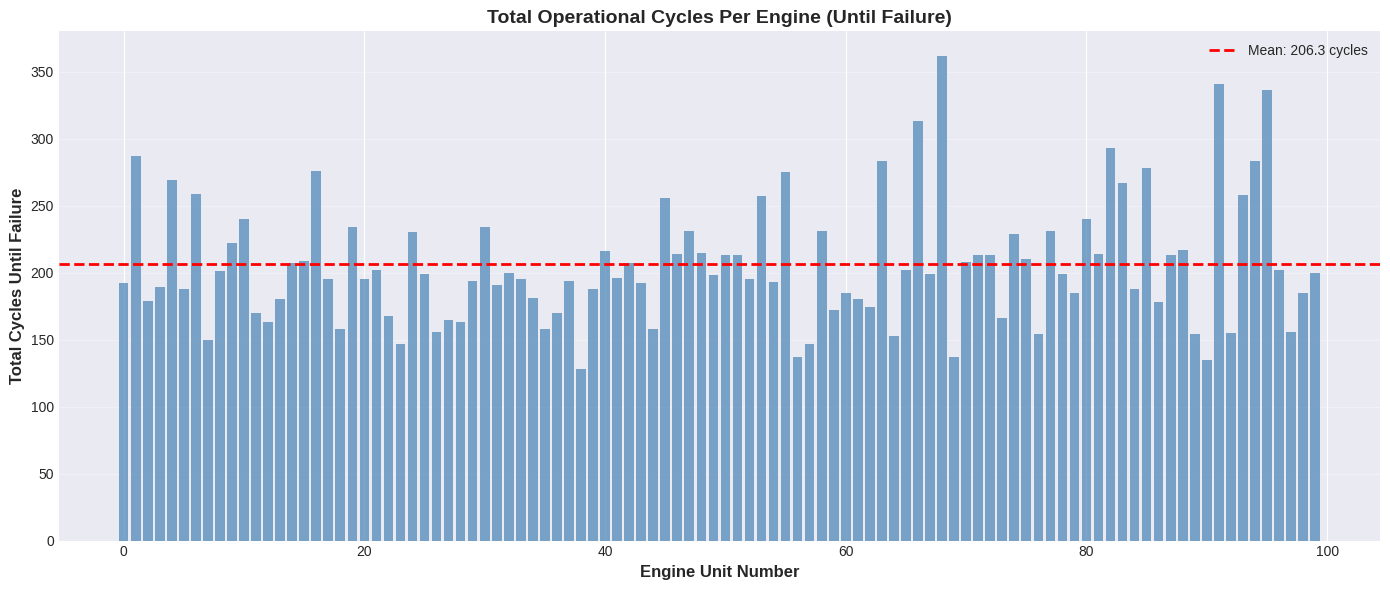

📊 Statistics:
   Mean cycles: 206.31
   Min cycles: 128
   Max cycles: 362
   Std Dev: 46.34


In [26]:
# Visualize total cycles per engine
total_cycles = train_df.groupby('unit')['time'].max()

plt.figure(figsize=(14, 6))
plt.bar(range(len(total_cycles)), total_cycles.values, color='steelblue', alpha=0.7)
plt.xlabel('Engine Unit Number', fontsize=12, fontweight='bold')
plt.ylabel('Total Cycles Until Failure', fontsize=12, fontweight='bold')
plt.title('Total Operational Cycles Per Engine (Until Failure)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# Add mean line
mean_cycles = total_cycles.mean()
plt.axhline(mean_cycles, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_cycles:.1f} cycles')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"📊 Statistics:")
print(f"   Mean cycles: {mean_cycles:.2f}")
print(f"   Min cycles: {total_cycles.min()}")
print(f"   Max cycles: {total_cycles.max()}")
print(f"   Std Dev: {total_cycles.std():.2f}")

## 🎓 Summary and Key Takeaways

Congratulations! You've learned how to:

### ✅ What You've Accomplished:

1. **DataFrames**:
   - Loaded CSV files into pandas DataFrames
   - Explored data structure and content
   - Used methods like `.head()`, `.info()`, `.describe()`

2. **Data Exploration**:
   - Examined column names and data types
   - Calculated summary statistics
   - Grouped data by engine units

3. **Visualizations**:
   - **Line plots**: Time series data
   - **Histograms**: Data distributions
   - **Box plots**: Data spread and outliers
   - **Scatter plots**: Relationships between variables
   - **Heatmaps**: Correlation matrices
   - **Subplots**: Multiple plots in one figure

4. **Data Understanding**:
   - Compared training vs test data
   - Analyzed RUL (Remaining Useful Life)
   - Visualized engine degradation patterns

### 📚 Key Concepts:

- **DataFrame**: Two-dimensional data structure (rows × columns)
- **CSV**: Comma-separated values file format
- **Visualization**: Graphical representation of data
- **Correlation**: Relationship between variables
- **RUL**: Remaining Useful Life (target for prediction)

### 🚀 Next Steps:

Now that you understand the data, you can:
1. Build machine learning models to predict RUL
2. Explore other datasets (FD002, FD003, FD004)
3. Create more advanced visualizations
4. Perform feature engineering

---

**Happy Learning! 📊✨**

## 📝 Practice Exercises

Try these exercises to reinforce your learning:

1. **Load FD002 dataset** and compare it with FD001
2. **Create a scatter plot** showing relationship between Nf and Nc (fan and compressor speeds)
3. **Plot all temperature sensors** (T2, T24, T30, T50) for engine #10
4. **Calculate correlation** between operational settings (Altitude, Mach, TRA) and sensor readings
5. **Create a box plot** comparing sensor values across different engines

Good luck! 🎯